# Una helada en flor: los péptidos que salvan la cosecha

**Una sola noche de frío durante la floración y un cultivo entero puede quedar estéril.** El polen aborta, los granos no se forman, y la pérdida ya está hecha antes de que salga el sol.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

Un equipo encontró en el tomate dos péptidos diminutos —**SlRGF9** y **SlRGF10**— que se encienden con el frío y le ordenan al polen que aguante. Quítalos, y el polen colapsa apenas baja la temperatura. Súbelos, y la planta protege su cosecha. Y lo más raro: el mismo truco funciona en arroz.

Abrimos los datos del paper para verlo nosotros mismos.

**Paper:** [Cold-induced peptide signalling secures pollen resilience and crop yield](https://doi.org/10.1038/s41586-026-10603-7)
*Nature · 2026-06-03 · DOI: [10.1038/s41586-026-10603-7](https://doi.org/10.1038/s41586-026-10603-7)*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-07-peptidos-frio-polen-cultivos/notebook.ipynb)

*Video del canal: [Ver en YouTube](https://youtube.com/shorts/DcE-aPw5fE8)*

## ¿Qué midieron?

El polen es el punto más frágil de una planta frente al frío. Si la flor pasa frío justo cuando madura el polen, los granos de polen mueren y no hay fruto. El equipo hizo tres cosas con tomate y arroz:

1. **Apagaron** los péptidos con CRISPR (mutantes `Slrgf9`, `Slrgf10`, y el doble mutante) y midieron la **viabilidad del polen** a temperatura normal (25 °C) y bajo frío (12 °C).
2. **Subieron** los péptidos (líneas de sobreexpresión) y midieron la **producción reproductiva** del tomate.
3. Repitieron el experimento de rendimiento en **arroz** —una planta muy lejana del tomate— para ver si el mecanismo se conserva.

Tres paneles de datos abiertos (los Source Data que Nature publica junto al paper). Vamos uno por uno.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TEMP_NORMAL = '25C'          # Temperatura control
TEMP_FRIO = '12C'            # Temperatura de estrés por frío
FUENTE = 'Fuente: Nature (2026), Cold-induced peptide signalling | Datos: Source Data MOESM5'
COLOR_DATOS = '#2563EB'      # Azul CaM (datos principales / 25 °C)
COLOR_ALERTA = '#DC2626'     # Rojo (frío / colapso)
COLOR_OK = '#059669'         # Emerald (líneas que sí rinden)
COLOR_REFERENCIA = '#D97706' # Amber (umbral / WT)
COLOR_GRIS = '#BBBBBB'       # Gris (contexto / línea débil)

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los tres paneles
polen = pd.read_csv('datos/pollen_viability_cold.csv')
tomate = pd.read_csv('datos/fig5e_tomato_yield.csv')
arroz = pd.read_csv('datos/fig5l_rice_yield.csv')

print(f'Polen (Fig. 1f):  {len(polen)} mediciones, {polen.genotype.nunique()} genotipos x 2 temperaturas')
print(f'Tomate (Fig. 5e): {len(tomate)} plantas, {tomate.genotype.nunique()} genotipos')
print(f'Arroz (Fig. 5l):  {len(arroz)} plantas, {arroz.genotype.nunique()} genotipos')
print()
print('Viabilidad de polen a 12 °C (media por genotipo):')
for g in ['WT', 'Slrgf9', 'Slrgf10', 'Slrgf9_Slrgf10']:
    v = polen[(polen.temp == TEMP_FRIO) & (polen.genotype == g)].pollen_viability
    print(f'  {g:18s} {v.mean():.3f}  (n={len(v)})')

Polen (Fig. 1f):  48 mediciones, 4 genotipos x 2 temperaturas
Tomate (Fig. 5e): 15 plantas, 3 genotipos
Arroz (Fig. 5l):  16 plantas, 4 genotipos

Viabilidad de polen a 12 °C (media por genotipo):
  WT                 0.906  (n=6)
  Slrgf9             0.835  (n=6)
  Slrgf10            0.819  (n=6)
  Slrgf9_Slrgf10     0.426  (n=6)


## El experimento clave

A 25 °C todos los genotipos tienen el polen sano. La pregunta es qué pasa cuando llega el frío.

Aquí está.

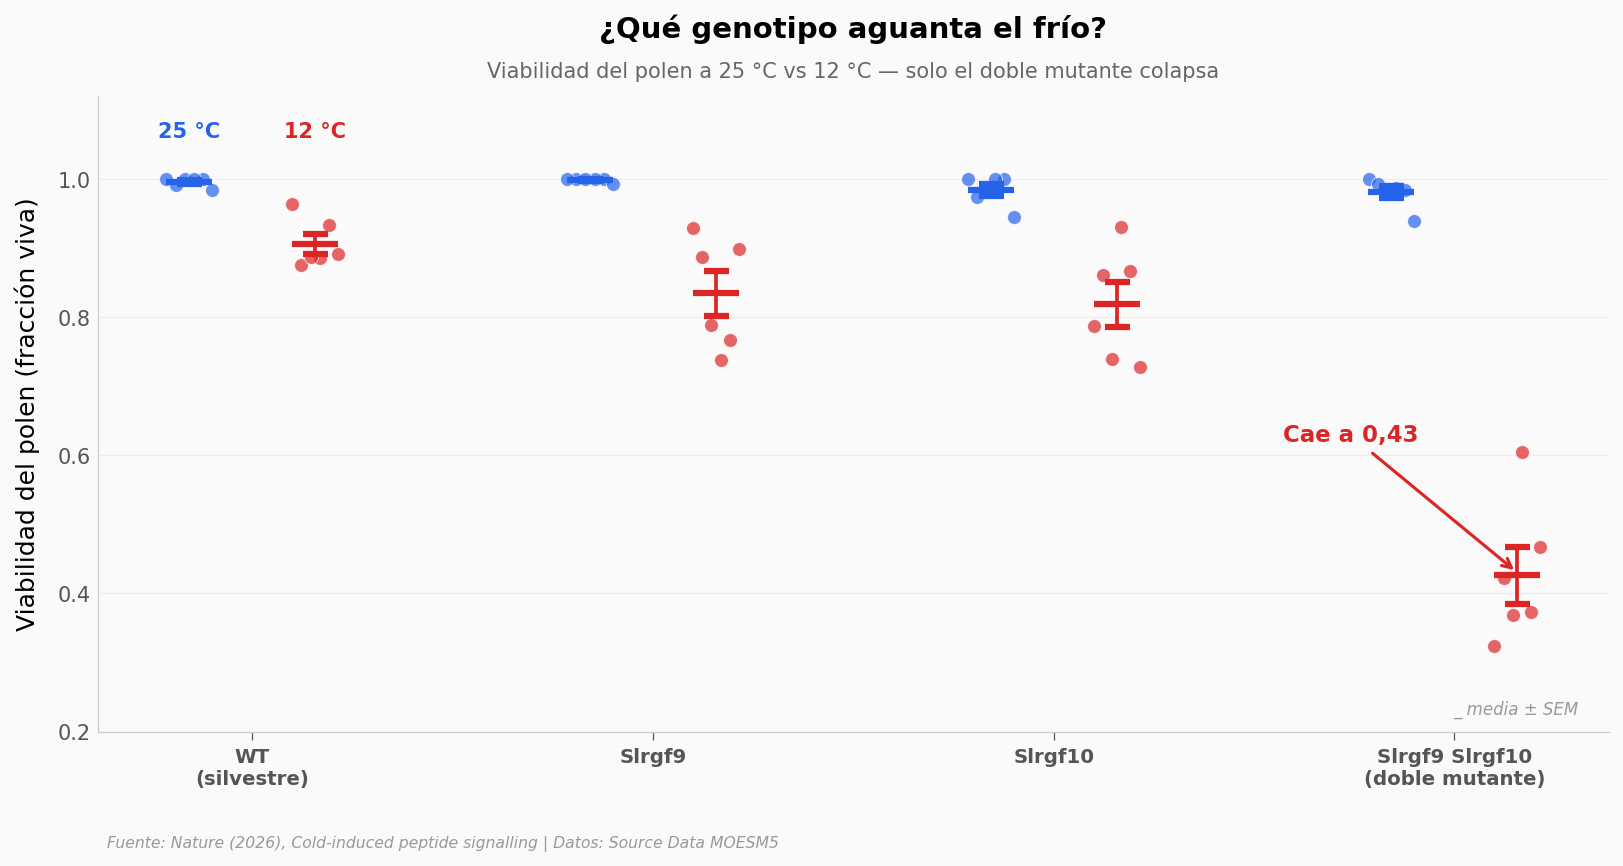

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))
np.random.seed(42)

genotipos = ['WT', 'Slrgf9', 'Slrgf10', 'Slrgf9_Slrgf10']
etiquetas = ['WT\n(silvestre)', 'Slrgf9', 'Slrgf10', 'Slrgf9 Slrgf10\n(doble mutante)']
posiciones = [0, 1.4, 2.8, 4.2]
offset = 0.22

for i, g in enumerate(genotipos):
    for temp, color, off in [(TEMP_NORMAL, COLOR_DATOS, -offset), (TEMP_FRIO, COLOR_ALERTA, offset)]:
        vals = polen[(polen.temp == temp) & (polen.genotype == g)].pollen_viability.values
        n = len(vals)
        x = np.linspace(posiciones[i] + off - 0.08, posiciones[i] + off + 0.08, n)
        np.random.shuffle(x)
        ax.scatter(x, vals, color=color, s=45, alpha=0.7,
                   edgecolors='white', linewidths=0.5, zorder=5)
        mean = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(n)
        ax.errorbar(posiciones[i] + off, mean, yerr=sem, fmt='_', color=color,
                    markersize=22, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

# Inline labels de temperatura (reemplazan legend box)
ax.text(posiciones[0] - offset, 1.06, '25 °C', fontsize=10, color=COLOR_DATOS,
        fontweight='bold', ha='center')
ax.text(posiciones[0] + offset, 1.06, '12 °C', fontsize=10, color=COLOR_ALERTA,
        fontweight='bold', ha='center')

ax.set_xticks(posiciones)
ax.set_xticklabels(etiquetas, fontsize=9.5, fontweight='bold')
ax.set_ylabel('Viabilidad del polen (fracción viva)')
ax.set_ylim(0.2, 1.12)
ax.set_title('¿Qué genotipo aguanta el frío?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Viabilidad del polen a 25 °C vs 12 °C — solo el doble mutante colapsa',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotar el colapso del doble mutante
ax.annotate('Cae a 0,43', xy=(posiciones[3] + offset, 0.43),
            xytext=(posiciones[3] - 0.6, 0.62), fontsize=11, fontweight='bold',
            color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))
ax.text(0.98, 0.02, '_ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/viabilidad_polen.png', dpi=200, bbox_inches='tight')
plt.show()

A 25 °C no se distingue nada: los cuatro genotipos rondan 0,98–1,0. El frío es lo que separa el grano de la paja.

Y la separación es brutal. El silvestre apenas baja (de 0,996 a 0,906: un **9 %**). Los mutantes simples —solo uno de los dos péptidos apagado— resisten casi igual de bien. Pero apaga **los dos a la vez** y el polen se desploma a **0,43**: una caída del **56,6 %**.

Eso es lo interesante: hace falta perder ambos péptidos para romper la protección. Tener uno solo basta. Los dos péptidos se respaldan mutuamente —redundancia funcional— y por eso la planta normal nunca nota su ausencia hasta que llega el frío.

## ¿Y si en vez de quitarlos, los subimos?

Si apagar los péptidos rompe el polen, encenderlos de más debería protegerlo —y traducirse en más cosecha. El equipo sobreexpresó cada péptido en tomate y midió la producción reproductiva.

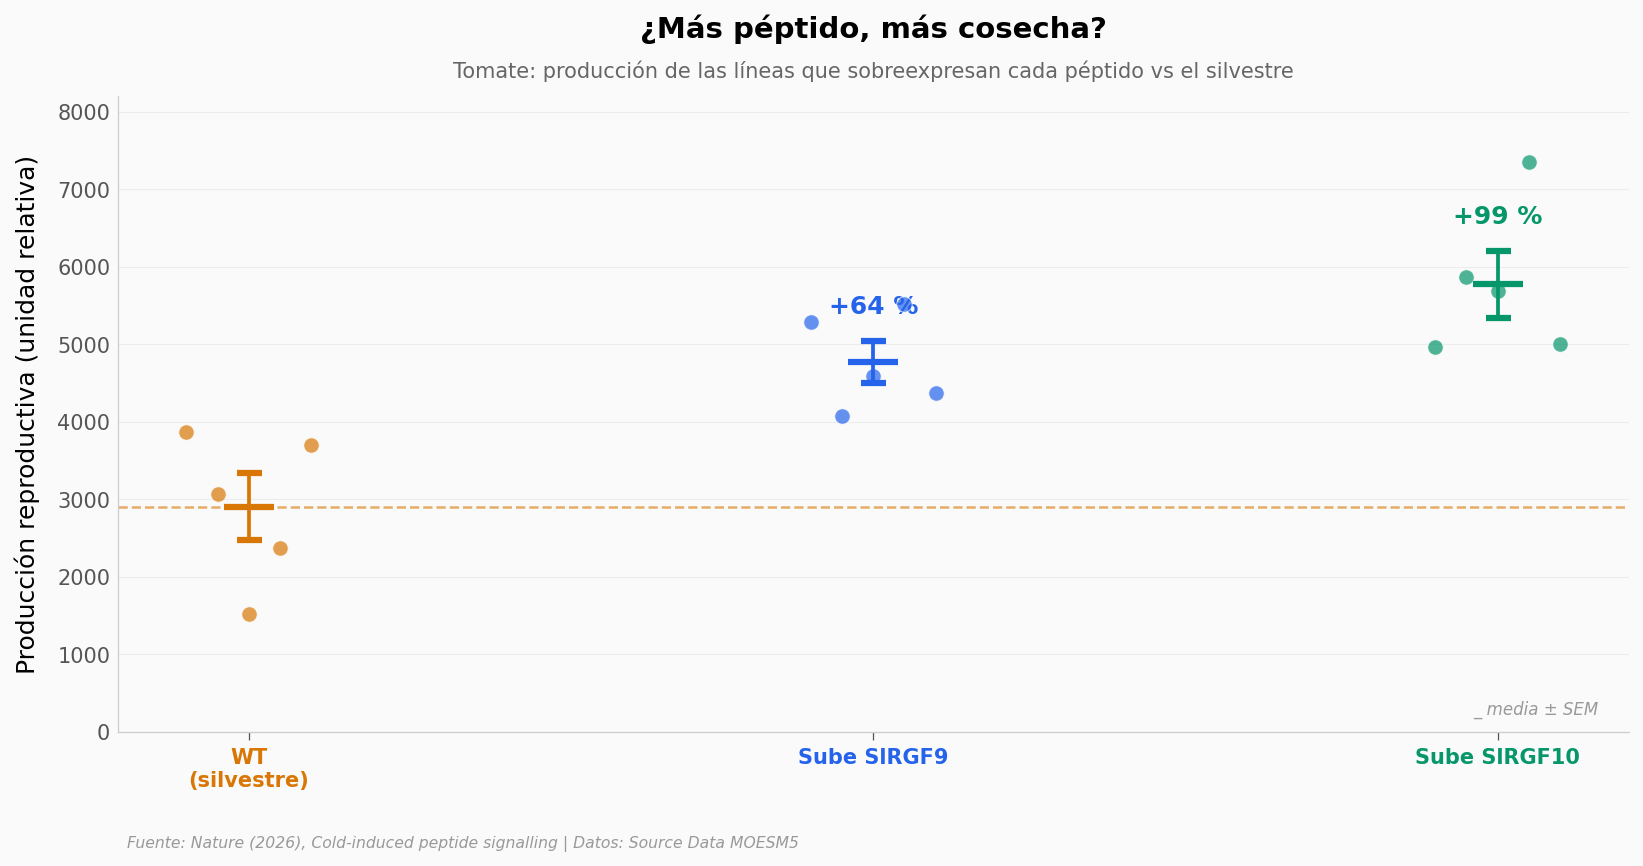

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))
np.random.seed(42)

grupos = ['WT', 'OE_SlRGF9', 'OE_SlRGF10']
etiquetas_t = ['WT\n(silvestre)', 'Sube SlRGF9', 'Sube SlRGF10']
colores_t = [COLOR_REFERENCIA, COLOR_DATOS, COLOR_OK]
posiciones_t = [0, 1, 2]

wt_mean = tomate[tomate.genotype == 'WT']['yield'].mean()
for i, g in enumerate(grupos):
    vals = tomate[tomate.genotype == g]['yield'].values
    n = len(vals)
    x = np.linspace(posiciones_t[i] - 0.1, posiciones_t[i] + 0.1, n)
    np.random.shuffle(x)
    ax.scatter(x, vals, color=colores_t[i], s=55, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(posiciones_t[i], mean, yerr=sem, fmt='_', color=colores_t[i],
                markersize=24, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    if g != 'WT':
        boost = (mean / wt_mean - 1) * 100
        ax.text(posiciones_t[i], mean + sem + 350, f'+{boost:.0f} %',
                fontsize=12, fontweight='bold', color=colores_t[i], ha='center')

ax.axhline(y=wt_mean, color=COLOR_REFERENCIA, linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_xticks(posiciones_t)
ax.set_xticklabels(etiquetas_t, fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colores_t):
    tick.set_color(color)
ax.set_ylabel('Producción reproductiva (unidad relativa)')
ax.set_ylim(0, 8200)
ax.set_title('¿Más péptido, más cosecha?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Tomate: producción de las líneas que sobreexpresan cada péptido vs el silvestre',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '_ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rendimiento_tomate.png', dpi=200, bbox_inches='tight')
plt.show()

## La prueba de fuego: ¿funciona en arroz?

El tomate y el arroz se separaron hace más de 150 millones de años —uno es dicotiledónea, el otro monocotiledónea—. Si el mismo péptido protege a los dos, el mecanismo es antiguo y general, no un truco de una sola especie.

El equipo subió el péptido equivalente (`OsRGF10`) en tres líneas de arroz independientes. Aquí conviene ser honestos: **las tres no rinden igual.**

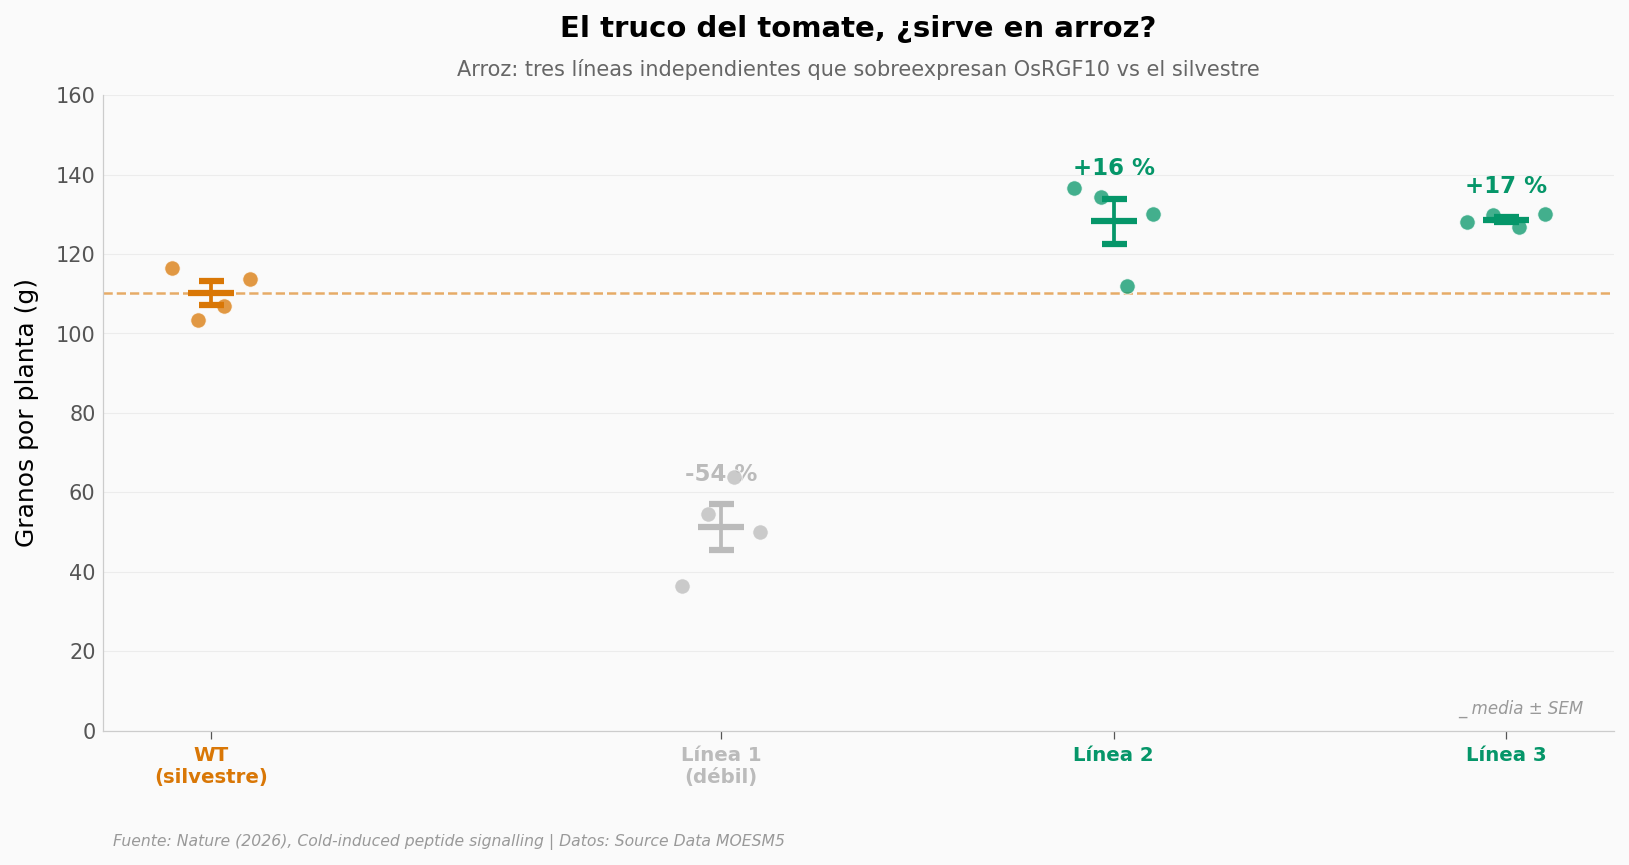

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))
np.random.seed(42)

grupos_r = ['ZH11_WT', 'OsRGF10_L1', 'OsRGF10_L2', 'OsRGF10_L3']
etiquetas_r = ['WT\n(silvestre)', 'Línea 1\n(débil)', 'Línea 2', 'Línea 3']
# L1 en gris: es una línea de bajo rendimiento, no se esconde
colores_r = [COLOR_REFERENCIA, COLOR_GRIS, COLOR_OK, COLOR_OK]
posiciones_r = [0, 1.3, 2.3, 3.3]

wt_arroz = arroz[arroz.genotype == 'ZH11_WT']['grain_yield'].mean()
for i, g in enumerate(grupos_r):
    vals = arroz[arroz.genotype == g]['grain_yield'].values
    n = len(vals)
    x = np.linspace(posiciones_r[i] - 0.1, posiciones_r[i] + 0.1, n)
    np.random.shuffle(x)
    ax.scatter(x, vals, color=colores_r[i], s=55, alpha=0.75,
               edgecolors='white', linewidths=0.5, zorder=5)
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(posiciones_r[i], mean, yerr=sem, fmt='_', color=colores_r[i],
                markersize=22, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    if g != 'ZH11_WT':
        boost = (mean / wt_arroz - 1) * 100
        signo = '+' if boost >= 0 else ''
        ax.text(posiciones_r[i], mean + sem + 6, f'{signo}{boost:.0f} %',
                fontsize=11, fontweight='bold', color=colores_r[i], ha='center')

ax.axhline(y=wt_arroz, color=COLOR_REFERENCIA, linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_xticks(posiciones_r)
ax.set_xticklabels(etiquetas_r, fontsize=9.5, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), colores_r):
    tick.set_color(color)
ax.set_ylabel('Granos por planta (g)')
ax.set_ylim(0, 160)
ax.set_title('El truco del tomate, ¿sirve en arroz?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Arroz: tres líneas independientes que sobreexpresan OsRGF10 vs el silvestre',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '_ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rendimiento_arroz.png', dpi=200, bbox_inches='tight')
plt.show()

La línea 1 rinde la mitad que el silvestre. Pero las líneas 2 y 3 suben un **+16 %** cada una, de forma consistente —en línea con el **18,3 %** que reporta el paper para el arroz—. ¿Por qué una línea falla? En transgénesis, el sitio del genoma donde cae la inserción cambia cuánto se expresa el gen; L1 quedó en un mal lugar. Por eso se hacen varias líneas: el efecto real es el que se repite, no el de una sola planta.

Volvamos al hallazgo central. Esa caída del polen a 0,43 en el doble mutante, ¿qué tan fuera de lo normal es comparada con un polen que sí tiene al menos un péptido bajo frío?

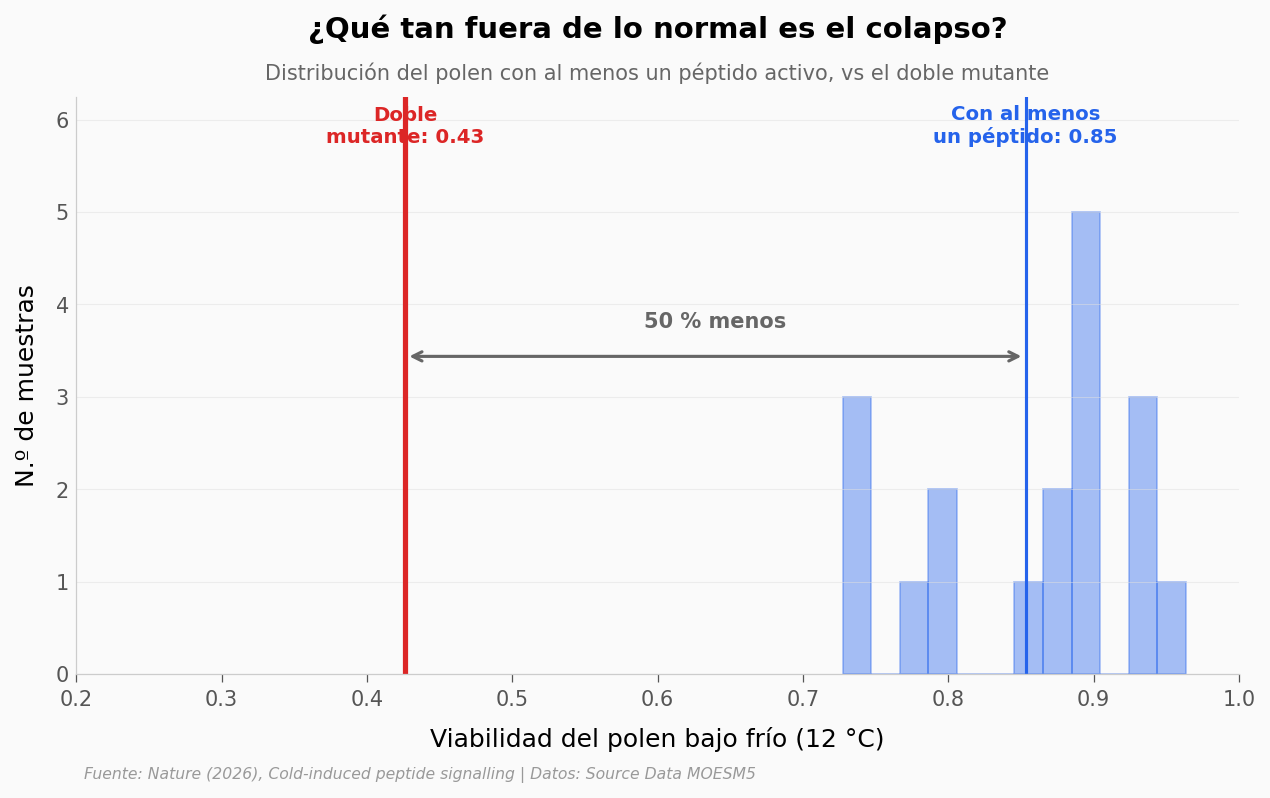

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# "Polen protegido bajo frío": WT + ambos mutantes simples a 12 °C (al menos un péptido activo)
protegido = polen[(polen.temp == TEMP_FRIO) &
                  (polen.genotype.isin(['WT', 'Slrgf9', 'Slrgf10']))].pollen_viability.values
doble_frio = polen[(polen.temp == TEMP_FRIO) &
                   (polen.genotype == 'Slrgf9_Slrgf10')].pollen_viability.values
media_protegido = protegido.mean()
media_doble = doble_frio.mean()

n, bins, patches = ax.hist(protegido, bins=12, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.25
ax.set_ylim(0, y_max)

ax.axvline(x=media_protegido, color=COLOR_DATOS, linewidth=1.5)
ax.text(media_protegido, y_max * 0.92, f'Con al menos\nun péptido: {media_protegido:.2f}',
        fontsize=9.5, color=COLOR_DATOS, fontweight='bold', ha='center')

ax.axvline(x=media_doble, color=COLOR_ALERTA, linewidth=2.5)
ax.text(media_doble, y_max * 0.92, f'Doble\nmutante: {media_doble:.2f}',
        fontsize=9.5, color=COLOR_ALERTA, fontweight='bold', ha='center')

ax.annotate('', xy=(media_doble, y_max * 0.55), xytext=(media_protegido, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media_doble + media_protegido) / 2, y_max * 0.6,
        f'{(media_protegido - media_doble) / media_protegido * 100:.0f} % menos',
        fontsize=10, color='#666666', ha='center', fontweight='bold')

ax.set_xlabel('Viabilidad del polen bajo frío (12 °C)')
ax.set_ylabel('N.º de muestras')
ax.set_xlim(0.2, 1.0)
ax.set_title('¿Qué tan fuera de lo normal es el colapso?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución del polen con al menos un péptido activo, vs el doble mutante',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_polen.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| A 25 °C ningún genotipo tiene defecto de polen | ✅ | Los cuatro genotipos rondan 0,98–1,0 a 25 °C. El efecto es específico de frío. |
| Bajo frío, solo el doble mutante colapsa | ✅ | WT 0,91 · simples 0,82–0,84 · doble **0,43**. Cohen's d (WT vs doble) = 6,4; Mann-Whitney p = 0,002 (n = 6/grupo). |
| Los dos péptidos son redundantes | ✅ | Apagar uno solo casi no afecta; hacen falta los dos para romper la protección. |
| Subir el péptido aumenta la cosecha de tomate | ✅ | +64 % (SlRGF9) y +99 % (SlRGF10) vs silvestre, en unidad relativa del panel (n = 5/grupo). |
| El mecanismo se conserva en arroz | ⚠️ | Dos de tres líneas suben +16 %; la tercera (L1) rinde menos. Consistente con el 18,3 % del paper, pero con una línea débil. |

> **Limitaciones:** muestras pequeñas (n = 4–6 por grupo). Los rendimientos están en unidades relativas del Source Data, no en kg/hectárea de campo abierto. La línea de arroz L1 rinde por debajo del silvestre —probable efecto del sitio de inserción del transgén—, así que el efecto positivo se sostiene en L2 y L3. Todo en condiciones controladas; falta validación en campo a gran escala.

## Ahora tú

Los datos están cargados. Tres preguntas para explorar:

1. **¿Cuánto pesa el frío sobre cada genotipo?** Calcula la caída porcentual de 25 °C a 12 °C para cada uno. Pista: agrupa `polen` por `genotype` y `temp`, saca la media, y compara.
2. **¿La línea de arroz L1 mueve el promedio?** Calcula el boost promediando solo L2 y L3, y luego incluyendo L1. ¿Cuánto cambia la historia?
3. **¿Cuán separados están los grupos a 12 °C?** Calcula el Cohen's d entre el silvestre y cada mutante simple bajo frío. ¿Alguno se acerca al doble mutante?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: caída por frío en cada genotipo
print('Caída de viabilidad de 25 °C a 12 °C por genotipo:')
for g in ['WT', 'Slrgf9', 'Slrgf10', 'Slrgf9_Slrgf10']:
    m25 = polen[(polen.temp == '25C') & (polen.genotype == g)].pollen_viability.mean()
    m12 = polen[(polen.temp == '12C') & (polen.genotype == g)].pollen_viability.mean()
    caida = (1 - m12 / m25) * 100
    print(f'  {g:18s} {m25:.3f} -> {m12:.3f}   cae {caida:4.1f} %')

# Pregunta 2: efecto en arroz con y sin la línea débil L1
wt_r = arroz[arroz.genotype == 'ZH11_WT']['grain_yield'].mean()
l2l3 = arroz[arroz.genotype.isin(['OsRGF10_L2', 'OsRGF10_L3'])]['grain_yield'].mean()
todas = arroz[arroz.genotype.str.startswith('OsRGF10')]['grain_yield'].mean()
print(f'\nArroz — boost solo L2+L3: {(l2l3/wt_r-1)*100:+.1f} %')
print(f'Arroz — boost con L1 incluida: {(todas/wt_r-1)*100:+.1f} %')

Caída de viabilidad de 25 °C a 12 °C por genotipo:
  WT                 0.996 -> 0.906   cae  9.0 %
  Slrgf9             0.999 -> 0.835   cae 16.4 %
  Slrgf10            0.984 -> 0.819   cae 16.8 %
  Slrgf9_Slrgf10     0.982 -> 0.426   cae 56.6 %

Arroz — boost solo L2+L3: +16.6 %
Arroz — boost con L1 incluida: -6.8 %


## Créditos

**Notebook:** Ciencia a Mordiscos — El Lab. Datos reproducibles, análisis abierto.

- **Paper:** [Cold-induced peptide signalling secures pollen resilience and crop yield](https://doi.org/10.1038/s41586-026-10603-7) · Nature, 2026
- **Datos originales:** Source Data (MOESM5) del paper, alojados por Nature/Springer
- **Licencia análisis:** CC BY 4.0 · **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

## Fuentes

**Paper**: [Cold-induced peptide signalling secures pollen resilience and crop yield](https://doi.org/10.1038/s41586-026-10603-7)  
*Nature, 2026-06-03*

**Source Data**: [Source Data for Cold-induced peptide signalling (MOESM5, Figs 1-5 + Extended Data)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10603-7/MediaObjects/41586_2026_10603_MOESM5_ESM.xlsx)

*16 afirmaciones del notebook verificadas contra estas fuentes*